# Market State And Alignment Builder

This notebook builds the market-side half of the upgraded counterfactual dataset and merges it with the release-aware macro output.

## What it does

- downloads the upgraded target universe from Yahoo Finance
- computes daily log returns
- computes rolling market-state features
- computes cross-asset spreads and rolling correlation summaries
- merges the market panel with the release-aware macro panel
- writes the aligned dataset used for the next DDPM retraining run

## Important note on futures

Yahoo's futures tickers are a practical prototype source, but they are not a perfect institutional continuous-contract data feed. In this notebook they are treated as provisional continuous proxies so we can move the pipeline forward. If you later switch to a proper back-adjusted futures source, the schema can stay the same while the data backend improves.

In [1]:
import importlib.util
import subprocess
import sys

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scipy": "scipy",
    "yfinance": "yfinance",
    "IPython": "IPython",
}

missing_packages = [
    package_name
    for module_name, package_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    print("Installing missing packages:", ", ".join(missing_packages))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
else:
    print("All required packages are already available.")

All required packages are already available.


In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from IPython.display import display

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## Configuration

This notebook reads the target universe and output locations from `dataset_spec_v1.json`, then reads the release-aware macro output produced by the macro loader notebook.

In [3]:
SPEC_PATH = Path("dataset_spec_v1.json")
ARTIFACT_ROOT = Path.cwd() / "counterfactual_data_build"

with open(SPEC_PATH, "r", encoding="utf-8") as handle:
    dataset_spec = json.load(handle)

target_specs = dataset_spec["targets"]
macro_output_relative = Path(dataset_spec["loader_outputs"]["macro_release_aware_daily_csv"])
market_output_relative = Path(dataset_spec["loader_outputs"]["market_panel_csv"])
aligned_output_relative = Path(dataset_spec["loader_outputs"]["aligned_dataset_csv"])

macro_path = ARTIFACT_ROOT / macro_output_relative
market_output_path = ARTIFACT_ROOT / market_output_relative
aligned_output_path = ARTIFACT_ROOT / aligned_output_relative
metadata_output_path = ARTIFACT_ROOT / "processed" / "market" / "market_builder_metadata.csv"

market_output_path.parent.mkdir(parents=True, exist_ok=True)
aligned_output_path.parent.mkdir(parents=True, exist_ok=True)

if not macro_path.exists():
    raise FileNotFoundError(
        f"Missing release-aware macro file: {macro_path}. Run release_aware_macro_loader.ipynb first."
    )

macro_daily = pd.read_csv(macro_path)
macro_daily["Date"] = pd.to_datetime(macro_daily["Date"]).dt.normalize()

display(pd.DataFrame(target_specs)[["symbol", "normalized_name", "asset_class", "target_column"]])
print("Macro input:", macro_path)
print("Market output:", market_output_path)
print("Aligned output:", aligned_output_path)

,symbol,normalized_name,asset_class,target_column
0,SPY,SPY,equity_etf,SPY_log_return
1,QQQ,QQQ,equity_etf,QQQ_log_return
2,GC=F,GC,gold_futures,GC_log_return
3,CL=F,CL,oil_futures,CL_log_return
4,ZN=F,ZN,rates_futures,ZN_log_return


Macro input: C:\Users\sammy\finance-ui\counterfactual_data_build\processed\macro\macro_release_aware_daily.csv
Market output: C:\Users\sammy\finance-ui\counterfactual_data_build\processed\market\market_daily_panel.csv
Aligned output: C:\Users\sammy\finance-ui\counterfactual_data_build\processed\aligned\aligned_counterfactual_dataset_v1.csv


## Download Market Data

This section downloads prices and volume for the upgraded target universe and normalizes column names so later feature engineering stays readable.

In [4]:
def choose_price_frame(raw_download):
    if raw_download is None or len(raw_download) == 0:
        raise RuntimeError("No market data returned from yfinance.")

    if isinstance(raw_download.columns, pd.MultiIndex):
        level0 = list(raw_download.columns.get_level_values(0).unique())
        if "Adj Close" in level0:
            prices = raw_download["Adj Close"].copy()
        elif "Close" in level0:
            prices = raw_download["Close"].copy()
        else:
            raise RuntimeError(f"Unexpected price columns: {level0}")

        volume = raw_download["Volume"].copy() if "Volume" in level0 else None
    else:
        price_column = "Adj Close" if "Adj Close" in raw_download.columns else "Close"
        ticker_name = raw_download.attrs.get("ticker", "asset")
        prices = raw_download[[price_column]].copy()
        prices.columns = [ticker_name]
        volume = raw_download[["Volume"]].copy() if "Volume" in raw_download.columns else None
        if volume is not None:
            volume.columns = [ticker_name]

    prices.index = pd.to_datetime(prices.index).normalize()
    prices = prices.sort_index().ffill()

    if volume is not None:
        volume.index = pd.to_datetime(volume.index).normalize()
        volume = volume.sort_index()

    return prices, volume


def download_target_history(target_specs, start_date, end_date):
    tickers = [item["symbol"] for item in target_specs]
    raw = yf.download(
        tickers,
        start=start_date,
        end=(pd.Timestamp(end_date) + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
        progress=False,
        auto_adjust=False,
        threads=False,
    )

    prices, volumes = choose_price_frame(raw)
    rename_map = {
        spec["symbol"]: spec["normalized_name"]
        for spec in target_specs
    }

    prices = prices.rename(columns=rename_map)
    if volumes is not None:
        volumes = volumes.rename(columns=rename_map)

    return prices, volumes


calendar_spec = dataset_spec["calendar"]
start_date = calendar_spec["start_date"]
end_date = pd.Timestamp.today().normalize().strftime("%Y-%m-%d")

price_df, volume_df = download_target_history(target_specs, start_date, end_date)
price_df = price_df.dropna(how="all").ffill()

print("Price frame shape:", price_df.shape)
display(price_df.tail())

Price frame shape: (4108, 5)


Ticker,CL,GC,QQQ,SPY,ZN
Date,,,,,
2026-04-23,95.8500,"4,705.1001",651.4200,708.4500,111.0469
2026-04-24,94.4000,"4,722.2998",663.8800,713.9400,111.2188
2026-04-27,96.3700,"4,675.3999",664.2300,715.1700,111.0312
2026-04-28,99.9300,"4,591.5000",657.5500,711.6900,110.8594
2026-04-29,107.1500,"4,540.0000",659.9200,709.9700,110.3750


## Market Feature Engineering

These are the first market-state features we want the next DDPM retraining run to see:

- 1d / 5d / 20d returns
- realized vol and downside semivol
- drawdown
- rolling skew and kurtosis
- optional volume shock for ETF targets

In [5]:
def rolling_max_drawdown(price_series, window=20):
    out = []
    values = price_series.astype(float).to_numpy()
    for idx in range(len(values)):
        start_idx = max(0, idx - window + 1)
        window_values = values[start_idx:idx + 1]
        running_max = np.maximum.accumulate(window_values)
        drawdowns = window_values / running_max - 1.0
        out.append(float(np.min(drawdowns)))
    return pd.Series(out, index=price_series.index)


def downside_semivol(return_series, window=20):
    def _downside(x):
        x = np.asarray(x, dtype=float)
        negatives = x[x < 0]
        if len(negatives) == 0:
            return 0.0
        return float(np.sqrt(np.mean(np.square(negatives))))

    return return_series.rolling(window, min_periods=window).apply(_downside, raw=True)


log_return_df = np.log(price_df / price_df.shift(1))
market_panel = pd.DataFrame(index=price_df.index)

metadata_rows = []

for spec in target_specs:
    asset = spec["normalized_name"]
    asset_class = spec["asset_class"]
    include_volume = bool(spec.get("include_volume", False))
    price_col = asset
    return_col = spec["target_column"]

    market_panel[f"{asset}_price"] = price_df[price_col]
    market_panel[return_col] = log_return_df[price_col]
    market_panel[f"{asset}_return_5d"] = log_return_df[price_col].rolling(5).sum()
    market_panel[f"{asset}_return_20d"] = log_return_df[price_col].rolling(20).sum()
    market_panel[f"{asset}_realized_vol_5d"] = log_return_df[price_col].rolling(5).std(ddof=0) * np.sqrt(252)
    market_panel[f"{asset}_realized_vol_20d"] = log_return_df[price_col].rolling(20).std(ddof=0) * np.sqrt(252)
    market_panel[f"{asset}_downside_semivol_20d"] = downside_semivol(log_return_df[price_col], window=20) * np.sqrt(252)
    market_panel[f"{asset}_max_drawdown_20d"] = rolling_max_drawdown(price_df[price_col], window=20)
    market_panel[f"{asset}_rolling_skew_20d"] = log_return_df[price_col].rolling(20).skew()
    market_panel[f"{asset}_rolling_kurtosis_20d"] = log_return_df[price_col].rolling(20).kurt()

    if include_volume and volume_df is not None and asset in volume_df.columns:
        vol_series = volume_df[asset].astype(float)
        market_panel[f"{asset}_volume"] = vol_series
        rolling_vol_mean = vol_series.rolling(20, min_periods=20).mean()
        rolling_vol_std = vol_series.rolling(20, min_periods=20).std(ddof=0)
        market_panel[f"{asset}_volume_shock_20d"] = (vol_series - rolling_vol_mean) / rolling_vol_std.replace(0.0, np.nan)

    metadata_rows.append(
        {
            "asset": asset,
            "symbol": spec["symbol"],
            "asset_class": asset_class,
            "include_volume": include_volume,
            "continuous_contract_required": bool(spec.get("continuous_contract_required", False)),
        }
    )

market_panel = market_panel.reset_index().rename(columns={"index": "Date"})
market_panel["Date"] = pd.to_datetime(market_panel["Date"]).dt.normalize()

display(market_panel.tail())

C:\Users\sammy\AppData\Roaming\Python\Python314\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


,Date,SPY_price,SPY_log_return,SPY_return_5d,SPY_return_20d,SPY_realized_vol_5d,SPY_realized_vol_20d,SPY_downside_semivol_20d,SPY_max_drawdown_20d,SPY_rolling_skew_20d,SPY_rolling_kurtosis_20d,SPY_volume,SPY_volume_shock_20d,QQQ_price,QQQ_log_return,QQQ_return_5d,QQQ_return_20d,QQQ_realized_vol_5d,QQQ_realized_vol_20d,QQQ_downside_semivol_20d,QQQ_max_drawdown_20d,QQQ_rolling_skew_20d,QQQ_rolling_kurtosis_20d,QQQ_volume,QQQ_volume_shock_20d,GC_price,GC_log_return,GC_return_5d,GC_return_20d,GC_realized_vol_5d,GC_realized_vol_20d,GC_downside_semivol_20d,GC_max_drawdown_20d,GC_rolling_skew_20d,GC_rolling_kurtosis_20d,CL_price,CL_log_return,CL_return_5d,CL_return_20d,CL_realized_vol_5d,CL_realized_vol_20d,CL_downside_semivol_20d,CL_max_drawdown_20d,CL_rolling_skew_20d,CL_rolling_kurtosis_20d,ZN_price,ZN_log_return,ZN_return_5d,ZN_return_20d,ZN_realized_vol_5d,ZN_realized_vol_20d,ZN_downside_semivol_20d,ZN_max_drawdown_20d,ZN_rolling_skew_20d,ZN_rolling_kurtosis_20d
4103,2026-04-23,708.4500,-0.0039,0.0096,0.0757,0.1208,0.1785,0.1581,-0.0203,0.1899,0.7116,"56,174,000.0000",-0.5321,651.4200,-0.0056,0.0170,0.1027,0.1495,0.2203,0.2138,-0.0270,-0.0745,0.3220,"40,099,800.0000",-0.7034,"4,705.1001",-0.0058,-0.0169,0.0336,0.2109,0.2823,0.2928,-0.0328,-0.4698,-0.0215,95.8500,0.0306,0.0122,0.0594,1.0276,1.0112,1.5088,-0.2576,-1.4356,2.5934,111.0469,-0.0021,-0.0015,0.0014,0.0419,0.0430,0.0391,-0.0060,0.0156,1.0373
4104,2026-04-24,713.9400,0.0077,0.0053,0.1014,0.1047,0.1602,0.1246,-0.0085,0.3958,1.2285,"45,182,000.0000",-0.8401,663.8800,0.0189,0.0229,0.1458,0.1718,0.1974,0.1595,-0.0076,0.1097,0.2177,"45,563,100.0000",-0.3337,"4,722.2998",0.0036,-0.0282,0.0763,0.1694,0.2402,0.2200,-0.0328,-0.1672,-0.2948,94.4000,-0.0152,0.1185,-0.0008,0.4274,1.0010,1.3999,-0.2576,-1.3417,2.5065,111.2188,0.0015,-0.0045,0.0095,0.0261,0.0360,0.0248,-0.0060,0.7820,0.3073
4105,2026-04-27,715.1700,0.0017,0.0091,0.1203,0.1019,0.1390,0.0610,-0.0085,1.1407,1.4552,"33,135,900.0000",-1.1591,664.2300,0.0005,0.0266,0.1661,0.1649,0.1735,0.0853,-0.0070,0.6657,-0.0300,"32,717,000.0000",-0.9872,"4,675.3999",-0.0100,-0.0277,0.0400,0.1686,0.2300,0.2140,-0.0375,-0.0303,-0.1451,96.3700,0.0207,0.0727,-0.0334,0.2645,0.9855,1.3999,-0.2576,-1.3533,2.6876,111.0312,-0.0017,-0.0056,0.0079,0.0264,0.0367,0.0262,-0.0062,0.8021,0.1827
4106,2026-04-28,711.6900,-0.0049,0.0108,0.1188,0.0952,0.1404,0.0660,-0.0085,1.0983,1.3734,"43,066,700.0000",-0.7140,657.5500,-0.0101,0.0203,0.1637,0.1860,0.1765,0.1000,-0.0101,0.5826,-0.0207,"34,041,200.0000",-0.8195,"4,591.5000",-0.0181,-0.0230,0.0144,0.1456,0.2391,0.2225,-0.0548,0.1188,-0.4378,99.9300,0.0363,0.0813,-0.0291,0.2903,0.9874,1.3999,-0.2576,-1.3528,2.6643,110.8594,-0.0015,-0.0039,0.0004,0.0213,0.0311,0.0261,-0.0077,0.6628,-0.1548
4107,2026-04-29,709.9700,-0.0024,-0.0017,0.0877,0.0733,0.1161,0.0623,-0.0085,0.9399,1.6163,"24,514,855.0000",-1.7314,659.9200,0.0036,0.0073,0.1340,0.1580,0.1513,0.1000,-0.0101,0.4382,-0.0315,"20,236,599.0000",-1.8475,"4,540.0000",-0.0113,-0.0415,-0.0234,0.1138,0.2230,0.2189,-0.0654,0.2172,-0.1440,107.1500,0.0698,0.1421,0.0554,0.4343,1.0160,1.5091,-0.2576,-1.3815,2.5004,110.3750,-0.0044,-0.0082,-0.0061,0.0300,0.0337,0.0320,-0.0120,0.4907,0.2708


## Cross-Asset Features

These summarize relative moves and co-movement regimes rather than only individual asset behavior.

In [6]:
core_assets = {spec["normalized_name"] for spec in target_specs}

required_assets = {"SPY", "QQQ", "GC", "CL", "ZN"}
missing_assets = required_assets - core_assets
if missing_assets:
    raise ValueError(f"Target universe missing required assets for cross-asset features: {missing_assets}")

market_panel = market_panel.sort_values("Date").reset_index(drop=True)
market_panel["gold_minus_equity_return_5d"] = market_panel["GC_return_5d"] - market_panel["SPY_return_5d"]
market_panel["oil_minus_equity_return_5d"] = market_panel["CL_return_5d"] - market_panel["SPY_return_5d"]
market_panel["growth_minus_broad_equity_return_5d"] = market_panel["QQQ_return_5d"] - market_panel["SPY_return_5d"]
market_panel["rates_minus_equity_return_5d"] = market_panel["ZN_return_5d"] - market_panel["SPY_return_5d"]

return_columns = [
    "SPY_log_return",
    "QQQ_log_return",
    "GC_log_return",
    "CL_log_return",
    "ZN_log_return",
]

cross_asset_corr = []
returns_only = market_panel[return_columns]
for idx in range(len(market_panel)):
    start_idx = max(0, idx - 19)
    window = returns_only.iloc[start_idx:idx + 1]
    if len(window) < 20 or window.isna().any().any():
        cross_asset_corr.append(np.nan)
        continue
    corr_matrix = window.corr().to_numpy(dtype=float)
    upper_idx = np.triu_indices_from(corr_matrix, k=1)
    cross_asset_corr.append(float(np.nanmean(corr_matrix[upper_idx])))

market_panel["cross_asset_corr_20d"] = cross_asset_corr

equity_vol_cols = ["SPY_realized_vol_20d", "QQQ_realized_vol_20d"]
commodity_vol_cols = ["GC_realized_vol_20d", "CL_realized_vol_20d"]
rates_vol_cols = ["ZN_realized_vol_20d"]

market_panel["equity_realized_vol_20d"] = market_panel[equity_vol_cols].mean(axis=1)
market_panel["commodity_realized_vol_20d"] = market_panel[commodity_vol_cols].mean(axis=1)
market_panel["rates_realized_vol_20d"] = market_panel[rates_vol_cols].mean(axis=1)

display(market_panel[[
    "Date",
    "gold_minus_equity_return_5d",
    "oil_minus_equity_return_5d",
    "growth_minus_broad_equity_return_5d",
    "rates_minus_equity_return_5d",
    "cross_asset_corr_20d",
]].tail())

,Date,gold_minus_equity_return_5d,oil_minus_equity_return_5d,growth_minus_broad_equity_return_5d,rates_minus_equity_return_5d,cross_asset_corr_20d
4103,2026-04-23,-0.0266,0.0025,0.0073,-0.0112,0.1469
4104,2026-04-24,-0.0336,0.1132,0.0176,-0.0098,0.0661
4105,2026-04-27,-0.0367,0.0637,0.0175,-0.0147,0.1289
4106,2026-04-28,-0.0338,0.0705,0.0096,-0.0147,0.1934
4107,2026-04-29,-0.0398,0.1438,0.0091,-0.0064,0.1499


## Merge With Release-Aware Macro Panel

The result should be the first training-ready aligned dataset for the upgraded build.

In [7]:
aligned_df = market_panel.merge(macro_daily, on="Date", how="inner")
aligned_df = aligned_df.sort_values("Date").reset_index(drop=True)

before_dropna_rows = len(aligned_df)
aligned_df = aligned_df.dropna().reset_index(drop=True)
after_dropna_rows = len(aligned_df)

print("Aligned rows before dropna:", before_dropna_rows)
print("Aligned rows after dropna:", after_dropna_rows)
display(aligned_df.tail())

Aligned rows before dropna: 4108
Aligned rows after dropna: 3921


,Date,SPY_price,SPY_log_return,SPY_return_5d,SPY_return_20d,SPY_realized_vol_5d,SPY_realized_vol_20d,SPY_downside_semivol_20d,SPY_max_drawdown_20d,SPY_rolling_skew_20d,SPY_rolling_kurtosis_20d,SPY_volume,SPY_volume_shock_20d,QQQ_price,QQQ_log_return,QQQ_return_5d,QQQ_return_20d,QQQ_realized_vol_5d,QQQ_realized_vol_20d,QQQ_downside_semivol_20d,QQQ_max_drawdown_20d,QQQ_rolling_skew_20d,QQQ_rolling_kurtosis_20d,QQQ_volume,QQQ_volume_shock_20d,GC_price,GC_log_return,GC_return_5d,GC_return_20d,GC_realized_vol_5d,GC_realized_vol_20d,GC_downside_semivol_20d,GC_max_drawdown_20d,GC_rolling_skew_20d,GC_rolling_kurtosis_20d,CL_price,CL_log_return,CL_return_5d,CL_return_20d,CL_realized_vol_5d,CL_realized_vol_20d,CL_downside_semivol_20d,CL_max_drawdown_20d,CL_rolling_skew_20d,CL_rolling_kurtosis_20d,ZN_price,ZN_log_return,ZN_return_5d,ZN_return_20d,ZN_realized_vol_5d,ZN_realized_vol_20d,ZN_downside_semivol_20d,ZN_max_drawdown_20d,ZN_rolling_skew_20d,ZN_rolling_kurtosis_20d,gold_minus_equity_return_5d,oil_minus_equity_return_5d,growth_minus_broad_equity_return_5d,rates_minus_equity_return_5d,cross_asset_corr_20d,equity_realized_vol_20d,commodity_realized_vol_20d,rates_realized_vol_20d,FEDFUNDS_level,FEDFUNDS_delta,FEDFUNDS_z,DGS2_level,DGS2_delta,DGS2_z,DGS10_level,DGS10_delta,DGS10_z,T10Y2Y_level,T10Y2Y_delta,T10Y2Y_z,CPIAUCSL_level,CPIAUCSL_delta,CPIAUCSL_z,UNRATE_level,UNRATE_delta,UNRATE_z,PAYEMS_level,PAYEMS_delta,PAYEMS_z,INDPRO_level,INDPRO_delta,INDPRO_z,VIXCLS_level,VIXCLS_delta,VIXCLS_z,release_day_flag,days_since_cpi,days_since_fomc,days_since_nfp
3916,2026-04-23,708.4500,-0.0039,0.0096,0.0757,0.1208,0.1785,0.1581,-0.0203,0.1899,0.7116,"56,174,000.0000",-0.5321,651.4200,-0.0056,0.0170,0.1027,0.1495,0.2203,0.2138,-0.0270,-0.0745,0.3220,"40,099,800.0000",-0.7034,"4,705.1001",-0.0058,-0.0169,0.0336,0.2109,0.2823,0.2928,-0.0328,-0.4698,-0.0215,95.8500,0.0306,0.0122,0.0594,1.0276,1.0112,1.5088,-0.2576,-1.4356,2.5934,111.0469,-0.0021,-0.0015,0.0014,0.0419,0.0430,0.0391,-0.0060,0.0156,1.0373,-0.0266,0.0025,0.0073,-0.0112,0.1469,0.1994,0.6467,0.0430,3.6400,0.0000,-1.4223,3.7900,0.0100,0.6832,4.3000,0.0000,0.5121,0.5100,-0.0100,-0.7011,330.2930,0.0000,2.4099,4.3000,0.0000,-0.1088,"158,466.0000",0.0000,-2.1055,101.7898,0.0000,-1.4519,18.9200,-0.5800,0.0925,1,13,22,20
3917,2026-04-24,713.9400,0.0077,0.0053,0.1014,0.1047,0.1602,0.1246,-0.0085,0.3958,1.2285,"45,182,000.0000",-0.8401,663.8800,0.0189,0.0229,0.1458,0.1718,0.1974,0.1595,-0.0076,0.1097,0.2177,"45,563,100.0000",-0.3337,"4,722.2998",0.0036,-0.0282,0.0763,0.1694,0.2402,0.2200,-0.0328,-0.1672,-0.2948,94.4000,-0.0152,0.1185,-0.0008,0.4274,1.0010,1.3999,-0.2576,-1.3417,2.5065,111.2188,0.0015,-0.0045,0.0095,0.0261,0.0360,0.0248,-0.0060,0.7820,0.3073,-0.0336,0.1132,0.0176,-0.0098,0.0661,0.1788,0.6206,0.0360,3.6400,0.0000,-1.4098,3.8300,0.0400,0.9128,4.3400,0.0400,0.8081,0.5100,0.0000,-0.6961,330.2930,0.0000,2.3782,4.3000,0.0000,-0.1129,"158,466.0000",0.0000,-2.0786,101.7898,0.0000,-1.4389,19.3100,0.3900,0.2178,1,14,23,21
3918,2026-04-27,715.1700,0.0017,0.0091,0.1203,0.1019,0.1390,0.0610,-0.0085,1.1407,1.4552,"33,135,900.0000",-1.1591,664.2300,0.0005,0.0266,0.1661,0.1649,0.1735,0.0853,-0.0070,0.6657,-0.0300,"32,717,000.0000",-0.9872,"4,675.3999",-0.0100,-0.0277,0.0400,0.1686,0.2300,0.2140,-0.0375,-0.0303,-0.1451,96.3700,0.0207,0.0727,-0.0334,0.2645,0.9855,1.3999,-0.2576,-1.3533,2.6876,111.0312,-0.0017,-0.0056,0.0079,0.0264,0.0367,0.0262,-0.0062,0.8021,0.1827,-0.0367,0.0637,0.0175,-0.0147,0.1289,0.1562,0.6077,0.0367,3.6400,0.0000,-1.3974,3.8300,0.0000,0.9105,4.3400,0.0000,0.8071,0.5100,0.0000,-0.6932,330.2930,0.0000,2.3475,4.3000,0.0000,-0.1171,"158,466.0000",0.0000,-2.0526,101.7898,0.0000,-1.4260,19.3100,0.0000,0.2285,0,17,26,24
3919,2026-04-28,711.6900,-0.0049,0.0108,0.1188,0.0952,0.1404,0.0660,-0.0085,1.0983,1.3734,"43,066,700.0000",-0.7140,657.5500,-0.0101,0.0203,0.1637,0.1860,0.1765,0.1000,-0.0101,0.5826,-0.0207,"34,041,200.0000",-0.8195,"4,591.5000",-0.0181,-0.0230,0.0144,0.1456,0.239

## Save Outputs

In [8]:
market_metadata = pd.DataFrame(metadata_rows)
market_panel.to_csv(market_output_path, index=False)
aligned_df.to_csv(aligned_output_path, index=False)
market_metadata.to_csv(metadata_output_path, index=False)

print("Saved:")
print(market_output_path)
print(aligned_output_path)
print(metadata_output_path)

Saved:
C:\Users\sammy\finance-ui\counterfactual_data_build\processed\market\market_daily_panel.csv
C:\Users\sammy\finance-ui\counterfactual_data_build\processed\aligned\aligned_counterfactual_dataset_v1.csv
C:\Users\sammy\finance-ui\counterfactual_data_build\processed\market\market_builder_metadata.csv


## Diagnostics

These quick charts make it easy to sanity-check that the upgraded universe and derived features look stable enough before we push them into a training notebook.

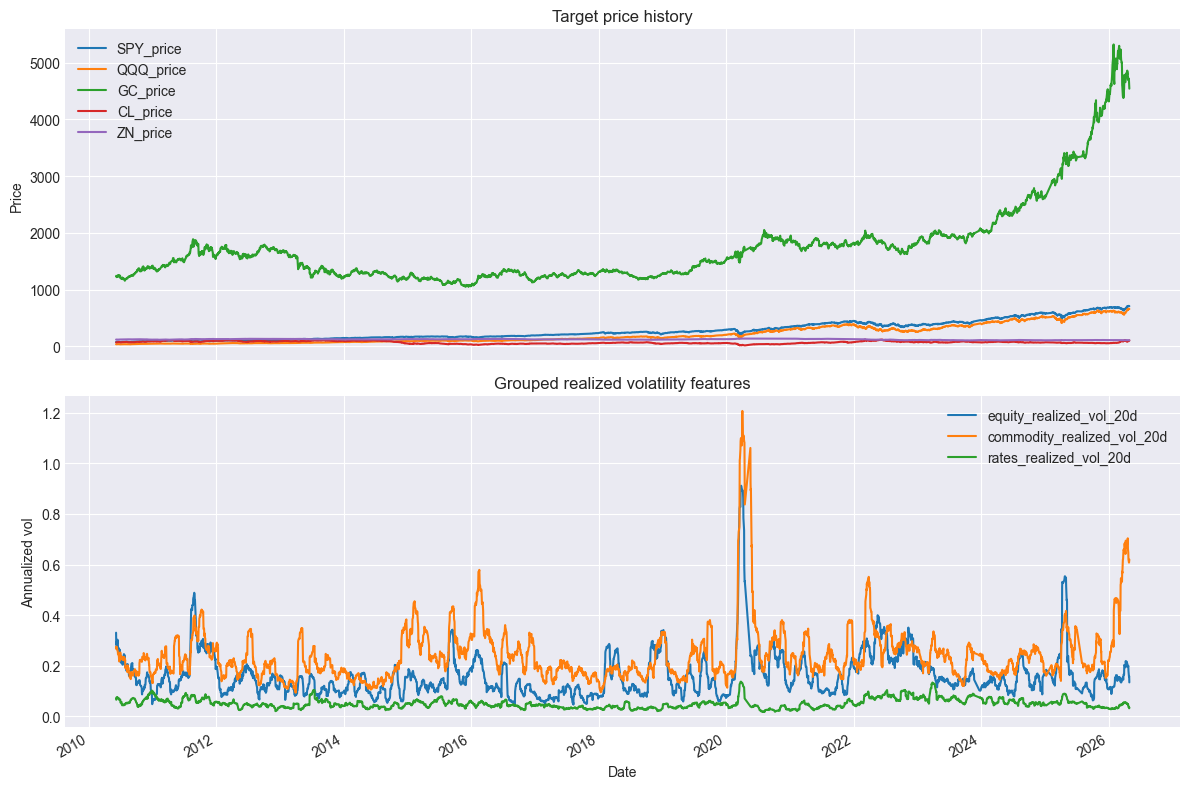

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

price_cols = [f"{spec['normalized_name']}_price" for spec in target_specs]
aligned_df.plot(x="Date", y=price_cols, ax=axes[0], linewidth=1.5)
axes[0].set_title("Target price history")
axes[0].set_ylabel("Price")

aligned_df.plot(
    x="Date",
    y=["equity_realized_vol_20d", "commodity_realized_vol_20d", "rates_realized_vol_20d"],
    ax=axes[1],
    linewidth=1.5,
)
axes[1].set_title("Grouped realized volatility features")
axes[1].set_ylabel("Annualized vol")

plt.tight_layout()
plt.show()